## Example 6.4-2
#### Kalman Filter Estimation of AoA in Gust Noise

In [1]:
import sys
sys.path.append('../')
import control as ct
import numpy as np
from scipy.optimize import brentq
from modeling.eqm import airdata
from modeling.params_f16 import Controls, F16Params
from tools.lin_f16 import get_lin_f16

TARGET_QBAR_PSf = 300.0
params = F16Params()
params.VT_ftps = 502.0
params.xcg = 0.35
params.alt_ft = brentq(
    lambda altitude_ft: airdata(params.VT_ftps, altitude_ft)[1] - TARGET_QBAR_PSf,
    -10000.0,
    35000.0,
)

lon_sys, _ = get_lin_f16(Controls(), params)
state_indices = [lon_sys.nstates.index("alpha_rad"), lon_sys.nstates.index("q_rps")]
output_indices = [lon_sys.noutputs.index("q_dps"),lon_sys.noutputs.index("nz_g_pilot")]
elevator_index = [lon_sys.ninputs.index("elev_deg")]

A = lon_sys.A[state_indices][:, state_indices]
B = lon_sys.B[state_indices][:, elevator_index]
B = np.append(B, np.array([[0.00203],[-0.00164]]), axis=1)
C = lon_sys.C[output_indices][:,state_indices]
C[0,1] = 1 # keep q in rad/s
D = lon_sys.D[output_indices][:,elevator_index]
D = np.append(D, np.zeros([D.shape[0], 1]), axis=1)

reduced_sys = ct.ss(A, B, C, D)
reduced_sys

Trim results:
Throttle (0-1): 0.26
Elevator (deg): -0.76
Alpha (deg): 2.11
Aileron (deg): 0.00
Rudder (deg): -0.00
Beta (deg): -0.00


<LinearIOSystem:sys[4]:['u[0]', 'u[1]']->['y[0]', 'y[1]']>

In [2]:
sys_act = ct.ss(-20.2, np.array([20.2, 0.0]), np.array([[1.0],[0.0]]), np.array([[0.0, 0.0],[0.0, 1.0]]))
sys2 = ct.series(sys_act, reduced_sys)
sys2

<LinearICSystem:sys[6]:['u[0]', 'u[1]']->['y[0]', 'y[1]']>

In [3]:
sig = 10 # ft/s gust amplitude
L = (1750.0)/(params.VT_ftps) # scale length over true airspeed
a_g = np.array([[ 0.0, 1.0],
                [ -1/L**2, -2/L]])
b_g = np.array([[0.0],
                [0.0]]) # u, w
c_g = np.zeros([2, 2])
c_g[1] = sig*np.sqrt(6/L)*np.array([[1/(L*np.sqrt(3)), 1.0]])
d_g = np.array([[1.0],
                [0.0]]) # u, w
sys_gust = ct.ss(a_g, b_g, c_g, d_g)
sys3 = ct.series(sys_gust, sys2)
sys3

<LinearICSystem:sys[9]:['u[0]']->['y[0]', 'y[1]']>

In [4]:
# Observability
np.linalg.matrix_rank(ct.obsv(sys3.A, sys3.C))

np.int64(5)

In [6]:
R = np.array([[1/20, 0], [0, 1/60]])

G = np.zeros((sys3.A.shape[0], 1))
G[1] = 1
Q_eff = G @ G.T
Q_eff
np.linalg.matrix_rank(ct.ctrb(sys3.A, Q_eff))

np.int64(4)

In [7]:
from scipy.linalg import solve_continuous_are
P = solve_continuous_are(sys3.A.T, sys3.C.T, Q_eff, R)
L = P @ sys3.C.T @ np.linalg.inv(R)
L 

array([[-4.84953502e-02,  5.20423949e+00],
       [-7.06393728e-02,  4.36803899e+00],
       [-5.19304903e-17,  3.99738734e-15],
       [-8.80601472e-04,  6.65101882e-02],
       [ 6.35005960e-04, -4.11460558e-02]])

In [8]:
kalman_filt = ct.ss(sys3.A - L @ sys3.C, np.hstack([sys3.B, L]), np.eye(sys3.A.shape[0]), np.zeros((sys3.A.shape[0], sys3.B.shape[1] + sys3.C.shape[0])))
alpha_est = kalman_filt[3,:]
alpha_est

StateSpace(array([[ 0.00000000e+00,  1.00000000e+00,  2.52971685e-01,
        -8.47324784e+01, -5.04999065e+00],
       [-8.22870204e-02, -5.73714286e-01,  2.12325007e-01,
        -7.11179357e+01, -4.20863826e+00],
       [ 0.00000000e+00,  0.00000000e+00, -2.02000000e+01,
        -6.50831955e-14, -3.86422737e-15],
       [ 4.41072050e-03,  2.66320439e-02,  1.08054596e-03,
        -2.10298561e+00,  8.40677864e-01],
       [-3.56334070e-03, -2.15155428e-02, -1.77808304e-01,
         1.49336280e+00, -1.03929790e+00]]), array([[ 0.00000000e+00, -4.84953502e-02,  5.20423949e+00],
       [ 0.00000000e+00, -7.06393728e-02,  4.36803899e+00],
       [ 2.02000000e+01, -5.19304903e-17,  3.99738734e-15],
       [ 0.00000000e+00, -8.80601472e-04,  6.65101882e-02],
       [ 0.00000000e+00,  6.35005960e-04, -4.11460558e-02]]), array([[0., 0., 0., 1., 0.]]), array([[0., 0., 0.]]))

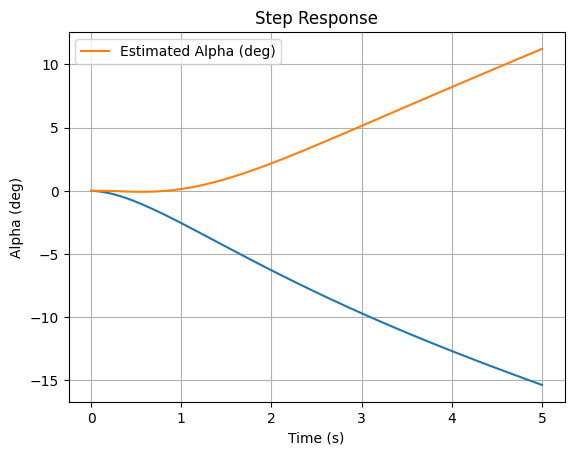

In [21]:
t = np.linspace(0, 5, 100)
import matplotlib.pyplot as plt
import tools.control_tools as tools
plt.figure()
y_q,_ = ct.step_response(lon_sys[3,1]/57.3, t)
y_nz,_ = ct.step_response(lon_sys[6,1], t)
u = np.zeros([3, t.shape[0]])
u[0,:] = 1
u[1,:] = y_q
u[2,:] = y_nz
t, y_a_est = ct.forced_response(alpha_est, t, u)
t, y = ct.step_response(lon_sys[1,1], t)
plt.plot(t, y.T)
plt.xlabel('Time (s)')
plt.ylabel('Alpha (deg)')
plt.title('Step Response')
plt.grid()
plt.plot(t, y_a_est[0]*57.3, label='Estimated Alpha (deg)')
plt.legend()
plt.show()